In [2]:
import pickle
import numpy as np
import faiss
import matplotlib.pyplot as plt

In [3]:
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/frequency_split/all_data_frequency_vectors_include_CSD.pkl", "rb") as f:
    all_freq_vectors_dict = pickle.load(f)

In [4]:
start = 0
prev_dataset = None
datasets = {}
for idx, index_name in enumerate(all_freq_vectors_dict['indexes']):
    curr_dataset = "_".join(index_name.split("_")[:-1])
    if prev_dataset is None:
        prev_dataset = curr_dataset
    if curr_dataset != prev_dataset:
        datasets[prev_dataset] = all_freq_vectors_dict['freq_vectors'][start:idx, :]
        start = idx
        prev_dataset = curr_dataset
    if idx == len(all_freq_vectors_dict['indexes'])-1:
        datasets[curr_dataset] = all_freq_vectors_dict['freq_vectors'][start:, :]

In [5]:
csd_dataset = np.concatenate([datasets['train_PS_300_torsion'], datasets['valid_PS_300_torsion']])
onehot_csd_dataset = (csd_dataset>0).astype(int)
csd_dataset.shape

(1767710, 440)

In [6]:
len(csd_dataset)*0.005

8838.550000000001

In [7]:
csd_dataset.sum(axis=1).mean(), csd_dataset.sum(axis=1).std()

(14.832877564758926, 5.808585105643436)

In [8]:
onehot_csd_dataset.sum(axis=1).mean(), onehot_csd_dataset.sum(axis=1).std()

(5.906178049566954, 1.744006491787738)

In [9]:
import random
def get_subset(dataset, num_subsample, num_neighbors=100, ensure_no_overlap=True):
    """
    Find a subset of the dataset such for each center index its num_neighbors are in the validation set.
    To ensure diversity of the subset we also ensure none of the center indexes share any neighbors with each other.
    Returns: center_indexes (list of indices), chosen_indexes (center indexes and their neighbours)
    """
    onehot_dataset = (dataset>0).astype(int)
    faiss_index = faiss.IndexFlat(onehot_dataset.shape[1], faiss.METRIC_L1)
    faiss_index.add(onehot_dataset)

    chosen_indexes = []
    remaining_indexes = set(np.arange(len(onehot_dataset)))
    random.seed(42)
    index = random.choice(list(remaining_indexes))
    num_centers = 0
    while len(chosen_indexes) < num_subsample:
        k = num_neighbors  # number of nearest neighbors
        D, I = faiss_index.search(onehot_dataset[index].reshape(1, -1), k)  # D is the distance, I is the index of neighbors
        I = I.flatten()
        assert index in I or D.mean() == 0
        if index not in I:
            I = np.concatenate([[index], I[:-1]])
        if len(chosen_indexes) == 0:
            chosen_indexes = I
            num_centers += 1
        else:
            new_chosen = I
            no_overlap = (len(set(chosen_indexes).intersection(set(new_chosen))) == 0)
            if no_overlap or not ensure_no_overlap:
                if not ensure_no_overlap:
                    chosen_indexes = np.concatenate([chosen_indexes, new_chosen])
                    chosen_indexes = np.unique(chosen_indexes)
                else: # no_overlap
                    chosen_indexes = np.concatenate([chosen_indexes, new_chosen])
                num_centers += 1
        print(num_centers, len(chosen_indexes), D.mean())
        remaining_indexes = remaining_indexes - set(chosen_indexes)
        index = random.choice(list(remaining_indexes))
    return chosen_indexes

In [10]:
indexes = get_subset(csd_dataset, 10000, num_neighbors=100, ensure_no_overlap=True)

1 100 1.83
2 200 1.9
3 300 0.91
4 400 1.71
5 500 2.65
6 600 1.65
7 700 1.9
8 800 0.66
9 900 3.88
10 1000 0.0
11 1100 0.92
12 1200 2.63
13 1300 2.64
14 1400 1.35
15 1500 4.4
16 1600 2.13
17 1700 2.54
18 1800 2.55
19 1900 2.85
20 2000 4.33
21 2100 1.27
22 2200 1.83
23 2300 1.42
24 2400 1.39
25 2500 0.0
26 2600 0.93
26 2600 0.89
26 2600 1.8
27 2700 0.0
27 2700 1.79
28 2800 0.77
29 2900 0.0
30 3000 1.82
30 3000 0.31
30 3000 1.78
31 3100 2.9
32 3200 0.0
33 3300 2.78
34 3400 0.71
35 3500 0.95
36 3600 1.56
37 3700 0.0
37 3700 3.23
38 3800 0.0
39 3900 4.59
40 4000 2.57
41 4100 0.71
42 4200 0.84
42 4200 1.08
43 4300 2.3
43 4300 3.37
44 4400 1.85
45 4500 0.0
46 4600 0.85
47 4700 1.58
48 4800 2.32
48 4800 2.34
49 4900 3.52
50 5000 3.43
50 5000 1.7
51 5100 2.35
51 5100 2.35
51 5100 0.78
51 5100 0.77
52 5200 1.76
53 5300 0.79
54 5400 0.7
55 5500 1.8
56 5600 0.5
57 5700 2.95
57 5700 1.69
57 5700 1.5
58 5800 3.24
59 5900 0.56
60 6000 1.44
61 6100 0.0
62 6200 0.89
63 6300 1.38
64 6400 2.68
65 6500 0.9

In [11]:
remaining_indexes = list(sorted(set(np.arange(len(csd_dataset))) - set(indexes)))
remaining_csd_dataset = csd_dataset[remaining_indexes]

In [12]:
test_indexes = get_subset(remaining_csd_dataset, 10000, num_neighbors=100, ensure_no_overlap=True)
test_indexes = [remaining_indexes[i] for i in test_indexes]

1 100 0.96
2 200 0.87
3 300 3.05
4 400 1.02
5 500 0.68
6 600 1.01
7 700 2.84
8 800 3.04
9 900 1.15
10 1000 0.95
11 1100 2.81
12 1200 2.48
13 1300 1.54
14 1400 2.66
15 1500 2.63
16 1600 0.0
17 1700 1.71
18 1800 1.78
19 1900 1.85
20 2000 0.8
21 2100 2.72
22 2200 2.3
23 2300 4.47
24 2400 1.45
25 2500 6.08
26 2600 2.36
26 2600 2.8
27 2700 3.39
28 2800 0.91
29 2900 0.26
30 3000 1.86
31 3100 1.62
32 3200 2.79
33 3300 0.97
34 3400 3.41
35 3500 2.69
36 3600 2.28
37 3700 1.26
38 3800 0.68
39 3900 2.58
40 4000 0.63
41 4100 1.68
42 4200 2.28
43 4300 2.42
44 4400 1.27
44 4400 0.87
45 4500 1.39
45 4500 1.9
45 4500 2.89
45 4500 2.42
46 4600 1.95
47 4700 2.73
48 4800 3.69
48 4800 3.4
48 4800 2.67
49 4900 1.31
49 4900 3.75
50 5000 1.6
51 5100 0.92
52 5200 1.22
53 5300 3.31
54 5400 2.9
55 5500 0.75
55 5500 2.09
56 5600 0.9
57 5700 2.69
58 5800 3.3
59 5900 2.9
60 6000 0.8
61 6100 0.65
62 6200 1.74
63 6300 3.07
63 6300 2.09
64 6400 3.72
65 6500 1.64
66 6600 1.91
67 6700 0.79
68 6800 0.0
69 6900 1.57
69 6

In [13]:
len(set(test_indexes).intersection(set(indexes)))

0

In [15]:
all_data = []
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/CSD/train_PS_300_torsion.pkl", "rb") as f:
    data = pickle.load(f)
    all_data.extend(data)
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/CSD/valid_PS_300_torsion.pkl", "rb") as f:
    data = pickle.load(f)
    all_data.extend(data)
len(all_data)

1767710

In [19]:
def get_frequency_vector(sample):
    """
    Given a sample, return a frequency vector of blocks in the sample
    """
    num_block_types = 440
    blocks = np.array(sample["data"]["B"])
    unique_values, counts = np.unique(blocks, return_counts=True)
    frequency_vector = np.zeros(num_block_types)
    frequency_vector[unique_values] = counts
    return frequency_vector

np.allclose(get_frequency_vector(all_data[-1]), csd_dataset[-1])

True

In [24]:
test_data = [all_data[i] for i in test_indexes]
valid_data = [all_data[i] for i in indexes]
train_indexes = list(sorted(set(np.arange(len(all_data))) - set(indexes) - set(test_indexes)))
train_data = [all_data[i] for i in train_indexes]

In [25]:
set(train_indexes).intersection(set(test_indexes))

set()

In [21]:
len(train_data), len(valid_data), len(test_data), len(all_data)

(1747710, 10000, 10000, 1767710)

In [26]:
data_dir = "/n/holystore01/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/"
with open(f"{data_dir}/CSD_PS_300_train.pkl", "wb") as f:
    pickle.dump(train_data, f)
with open(f"{data_dir}/CSD_PS_300_valid.pkl", "wb") as f:
    pickle.dump(valid_data, f)
with open(f"{data_dir}/CSD_PS_300_test.pkl", "wb") as f:
    pickle.dump(test_data, f)

In [2]:
import pickle
data_dir = "/n/holystore01/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/"
with open(f"{data_dir}/CSD_PS_300_train.pkl", "rb") as f:
    train_data = pickle.load(f)
with open(f"{data_dir}/CSD_PS_300_valid.pkl", "rb") as f:
    valid_data = pickle.load(f)
with open(f"{data_dir}/CSD_PS_300_test.pkl", "rb") as f:
    test_data = pickle.load(f)

for item in train_data:
    item['data']['modality'] = 'CSD'
for item in valid_data:
    item['data']['modality'] = 'CSD'
for item in test_data:
    item['data']['modality'] = 'CSD'

with open(f"{data_dir}/CSD_PS_300_train_with_modality.pkl", "wb") as f:
    pickle.dump(train_data, f)
with open(f"{data_dir}/CSD_PS_300_valid_with_modality.pkl", "wb") as f:
    pickle.dump(valid_data, f)
with open(f"{data_dir}/CSD_PS_300_test_with_modality.pkl", "wb") as f:
    pickle.dump(test_data, f)


# subsample 10pc for hyperparameter tuning

In [27]:
# with open(f"{data_dir}/CSD_PS_300_train.pkl", "rb") as f:
#     csd_data = pickle.load(f)

train_indexes = list(range(len(train_data)))
random.seed(42)
random.shuffle(train_indexes)
subsample_train_indexes = train_indexes[:len(train_data)//10]
subsample_train = [train_data[i] for i in subsample_train_indexes]
with open(f"{data_dir}/CSD_PS_300_train_subsample10pc.pkl", "wb") as f:
    pickle.dump(subsample_train, f)
len(subsample_train)

174771

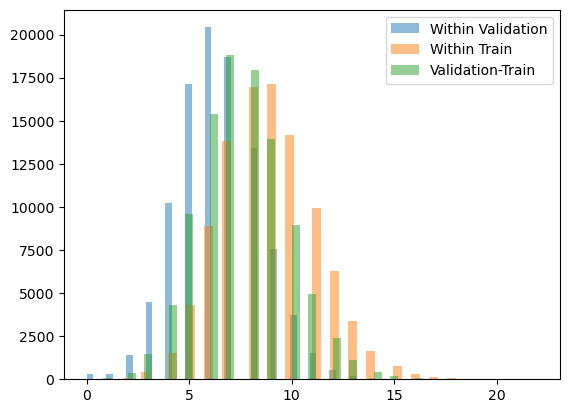

In [19]:

import random 
chosen_indexes = indexes

distances_within_validation = []
distances_validation_train = []
distances_within_train = []
num_pairs = 100000
train_indexes = np.array(list(set(range(len(onehot_csd_dataset))) - set(chosen_indexes)))

for i in range(num_pairs):
    idx1, idx2 = random.sample(chosen_indexes.tolist(), 2)
    dist = np.linalg.norm(onehot_csd_dataset[idx1] - onehot_csd_dataset[idx2], ord=1)
    distances_within_validation.append(dist)

indexes = random.sample(train_indexes.tolist(), 2*num_pairs)
for i in range(num_pairs):
    idx1, idx2 = indexes[i], indexes[i+num_pairs]
    dist = np.linalg.norm(onehot_csd_dataset[idx1] - onehot_csd_dataset[idx2], ord=1)
    distances_within_train.append(dist)

for i in range(num_pairs):
    idx1 = random.choice(chosen_indexes)
    idx2 = random.choice(train_indexes)
    dist = np.linalg.norm(onehot_csd_dataset[idx1] - onehot_csd_dataset[idx2], ord=1)
    distances_validation_train.append(dist)

plt.hist(distances_within_validation, bins=50, alpha=0.5, label='Within Validation')
plt.hist(distances_within_train, bins=50, alpha=0.5, label='Within Train')
plt.hist(distances_validation_train, bins=50, alpha=0.5, label='Validation-Train')
plt.legend(loc='upper right')
plt.show()


In [20]:
print(np.mean(distances_within_validation), np.std(distances_within_validation))
print(np.mean(distances_within_train), np.std(distances_within_train))
print(np.mean(distances_validation_train), np.std(distances_validation_train))

6.3587 1.9991634025261666
8.83953 2.335932229132515
7.6081 2.156171233923688


: 

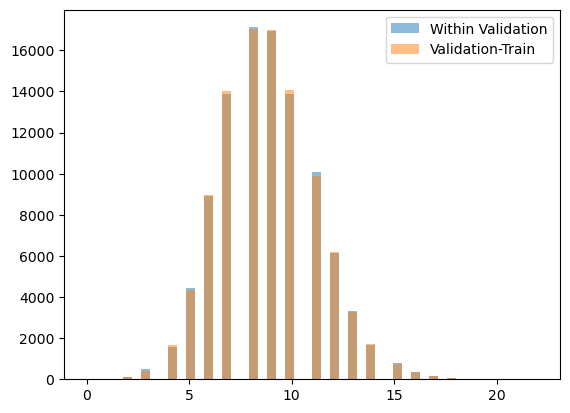

In [91]:
distances_within_validation_rand_split = []
distances_validation_train_rand_split = []
num_pairs = 100000
train_indexes = range(len(datasets['train_PS_300_torsion']))
valid_indexes = range(len(datasets['valid_PS_300_torsion']))

onehot_csd_train = (datasets['train_PS_300_torsion']>0).astype(int)
onehot_csd_valid = (datasets['valid_PS_300_torsion']>0).astype(int)

for i in range(num_pairs):
    idx1, idx2 = random.sample(valid_indexes, 2)
    dist = np.linalg.norm(onehot_csd_valid[idx1] - onehot_csd_valid[idx2], ord=1)
    distances_within_validation_rand_split.append(dist)

for i in range(num_pairs):
    idx1 = random.choice(valid_indexes)
    idx2 = random.choice(train_indexes)
    dist = np.linalg.norm(onehot_csd_valid[idx1] - onehot_csd_train[idx2], ord=1)
    distances_validation_train_rand_split.append(dist)

plt.hist(distances_within_validation_rand_split, bins=50, alpha=0.5, label='Within Validation')
plt.hist(distances_validation_train_rand_split, bins=50, alpha=0.5, label='Validation-Train')
plt.legend(loc='upper right')
plt.show()


In [93]:
print(np.mean(distances_within_validation_rand_split), np.std(distances_within_validation_rand_split))
print(np.mean(distances_validation_train_rand_split), np.std(distances_validation_train_rand_split))

8.82636 2.354487024895232
8.82141 2.34087923906809


In [62]:
random_index in np.array([random_index])

True

In [13]:
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/spectra_dataset/csd_valid_ids.txt", "r") as f:
    csd_valid_ids = f.readlines()
csd_valid_ids = [x.strip() for x in csd_valid_ids]

with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/spectra_dataset/csd_train_ids.txt", "r") as f:
    csd_train_ids = f.readlines()
csd_train_ids = [x.strip() for x in csd_train_ids]

csd_ids = csd_train_ids + csd_valid_ids
len(csd_ids)

1767710

XARBOJ_O=C1NC(=O)C=C(N1)C(=O)[O-]_3_O=C1NC(=O)C=C(N1)C(=O)[O-]_1


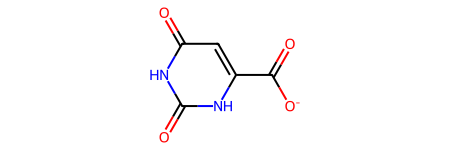

In [22]:
from rdkit import Chem
print(csd_ids[random_index])
smiles = csd_ids[random_index].split("_")[1]
mol = Chem.MolFromSmiles(smiles)
mol

HOXHIM_OC(=O)C1=CNC(=O)NC1=O_1_[nH+]1ccc(cc1)c1ccncc1_8


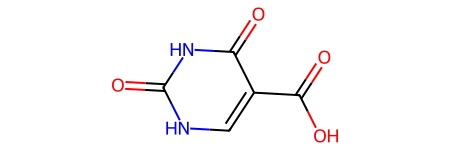

In [26]:
from rdkit import Chem
neighbour = I[0][4]
print(csd_ids[neighbour])
smiles = csd_ids[neighbour].split("_")[1]
mol = Chem.MolFromSmiles(smiles)
mol

In [3]:
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/spectra_dataset/validation_indexes/csd_validation_indexes.pkl", "rb") as f:
    csd_indexes = pickle.load(f)

In [5]:
csd_indexes['validation_indexes']

array([      0, 1284346,   39170, ..., 1490753, 1497741, 1512107])

In [15]:
with open(f"/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/CSD/train_PS_300_torsion.pkl", "rb") as f:
    train_data = pickle.load(f)

with open(f"/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/CSD/valid_PS_300_torsion.pkl", "rb") as f:
    valid_data = pickle.load(f)

all_data = train_data + valid_data

In [16]:
not_chosen_indexes = set(range(len(all_data))) - set(indexes)
len(indexes), len(not_chosen_indexes)

(10000, 1757710)

In [18]:
with open(f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/CSD_PS_300_train.pkl", "wb") as f:
    pickle.dump([all_data[i] for i in not_chosen_indexes], f)

with open(f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/CSD_PS_300_valid.pkl", "wb") as f:
    pickle.dump([all_data[i] for i in indexes], f)